# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [2]:
p = len(feature_cols)
n_pairs = comb(p, 2)
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs:,} -- too many plots for routine manual inspection.")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e} -- exhaustive coverage is computationally infeasible.")

p = 30 features
Unique pairwise relationships: 435 -- too many plots for routine manual inspection.
Grid cells needed (10 bins/dim): 1.00e+30 -- exhaustive coverage is computationally infeasible.


**Reflection:** A human could not inspect all 435 pairwise scatter plots carefully during one shift, and a 30-dimensional grid would be vastly larger still. Dimensionality reduction is therefore necessary to summarize shared structure before the pathologist examines individual relationships.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

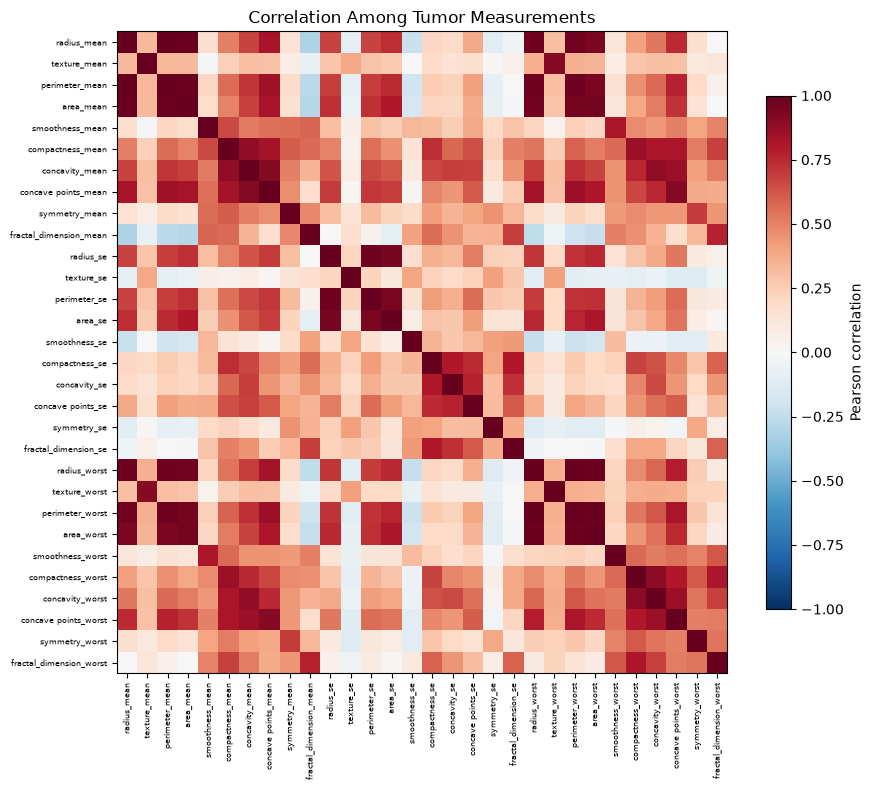

Highly correlated pairs (|r| > 0.9): 21


In [3]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)
ax.set_title("Correlation Among Tumor Measurements")
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson correlation")
plt.tight_layout()
plt.show()

upper_triangle = np.triu(np.ones(corr.shape, dtype=bool), k=1)
high_corr_pairs = int(((corr.abs() > 0.9) & upper_triangle).sum().sum())
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)

**Reflection:** `mean radius` and `mean perimeter` should be highly correlated because both measure the same underlying factor: the overall size of a tumor. The same reasoning applies to `mean radius` and `mean area`; as radius increases, the perimeter and area derived from the tumor boundary also increase.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

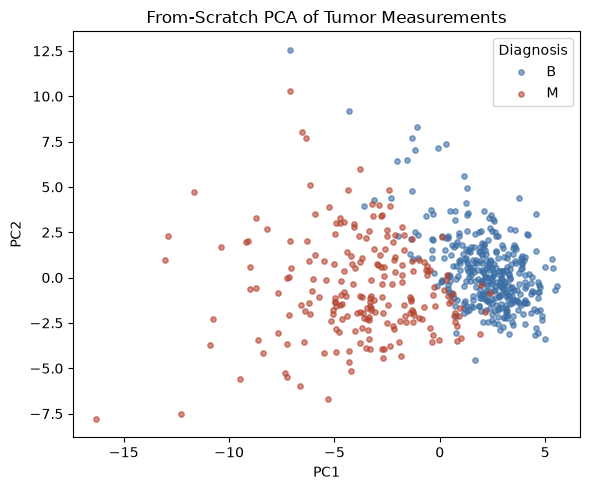

In [4]:
def pca_from_scratch(X, k):
    means = X.mean(axis=0)
    sample_stds = X.std(axis=0, ddof=1)
    X_scaled = (X - means) / sample_stds

    cov = np.cov(X_scaled, rowvar=False, ddof=1)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    Z = X_scaled @ eigvecs[:, :k]
    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("From-Scratch PCA of Tumor Measurements")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

**Reflection:** The PCA plot shows substantial separation, although some malignant and benign cases overlap near the boundary. That overlap does not mean PCA failed; it means the two directions that preserve the most overall variance do not preserve every diagnosis-related distinction from all 30 measurements.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

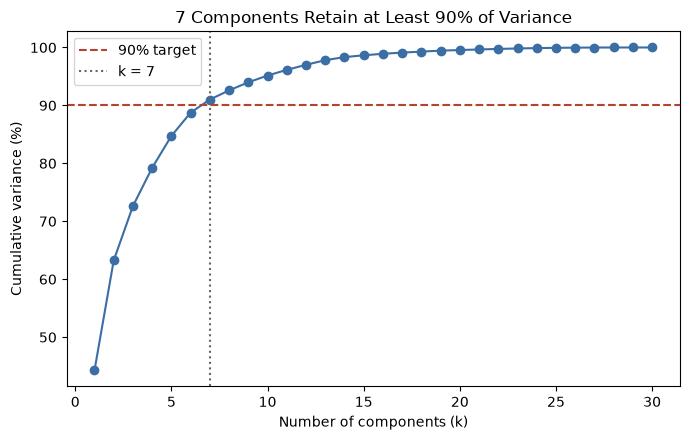

Two components retain 63.2% of variance; k=7 reaches 91.0%.


In [5]:
explained_ratio = eigvals / eigvals.sum()
cumulative = np.cumsum(explained_ratio)
k_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--", label="90% target")
ax.axvline(k_90, color="#666666", ls=":", label=f"k = {k_90}")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Cumulative variance (%)")
ax.set_title(f"{k_90} Components Retain at Least 90% of Variance")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Two components retain {cumulative[1]:.1%} of variance; k={k_90} reaches {cumulative[k_90 - 1]:.1%}.")

**Reflection:** The first two components retain only about 63% of the standardized dataset's variance, while seven components are needed to exceed 90%. A 2D poster therefore discards variation captured by components 3 through 7 and may hide clinically relevant distinctions or make overlapping cases appear more similar than they are in the fuller representation.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

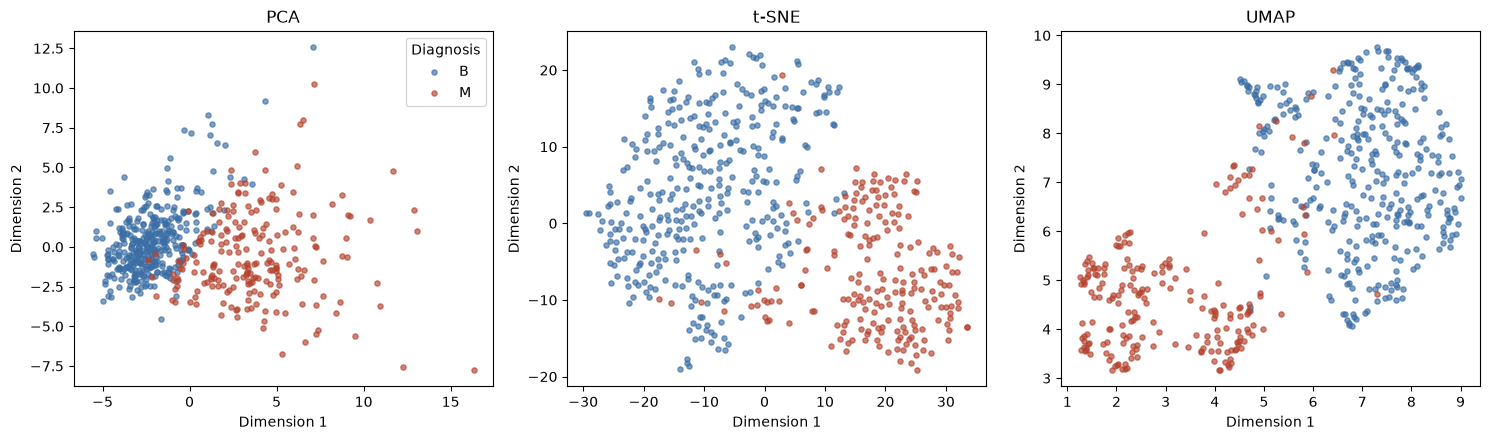

In [6]:
X_scaled = StandardScaler().fit_transform(X_raw)

pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
tsne_emb = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0,
    init="pca",
    learning_rate="auto",
).fit_transform(X_scaled)
umap_emb = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    n_jobs=1,
    random_state=0,
).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=14, alpha=0.65, color=color, label=label)
    ax.set_title(name)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

axes[0].legend(title="Diagnosis")
plt.tight_layout()
plt.show()

**Reflection:** UMAP gives the cleanest visual grouping on this run, with most benign and malignant cases occupying different neighborhoods, although a boundary region remains. It is not automatically the best method: PCA is faster and its linear axes and loadings are easier to explain, while t-SNE and UMAP emphasize local neighborhoods and can distort global distances.

## Task 6 — The Decision

I would use PCA as the default dashboard view because it is deterministic, fast, and easier to explain to a pathologist through feature loadings on linear components. The first two components retain about 63% of the standardized variance, so the dashboard should display that percentage and offer the seven-component result when more detail is needed. UMAP can remain a secondary exploratory view because it separates local neighborhoods more clearly in this dataset, but its axes do not have the same direct interpretation. I would not claim that a point's location proves a diagnosis or that the distance between two visible clusters is a calibrated clinical risk. The map should support investigation, not replace validated diagnostic criteria.